In [61]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import product
import os

In [62]:
!pip install ucimlrepo

In [63]:
RANDOM_STATE = 42

In [64]:
DATA_FOLDER = "data"
PATH = f"{DATA_FOLDER}/bank_marketing.csv"
SEP = ";"

if os.path.isfile(PATH):
    df = pd.read_csv(PATH, sep=SEP)
    X = df.drop(df.columns[-1], axis=1)
    y = df.drop(df.columns[:-1], axis=1)
else:
    from ucimlrepo import fetch_ucirepo
    bank_marketing = fetch_ucirepo(id=222)
    X = bank_marketing.data.features
    y = bank_marketing.data.targets
    df = X.join(y)
    os.makedirs(DATA_FOLDER, exist_ok=True)
    df.to_csv(PATH, sep=SEP, index=False)

In [65]:
X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome'],
      dtype='object')

In [66]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [67]:
target = y.columns[0]

print(target)

y


In [68]:
y.value_counts()

,count
y,
no,39922
yes,5289


In [69]:
# This attribute highly affects the output targe. Yet, the duration is not known before a call is performed
X = X.drop("duration", axis=1)

In [70]:
X_encoded = pd.get_dummies(X, dtype=int, dummy_na=True)
features = X_encoded.columns
print(features)

Index(['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_nan',
       'marital_divorced', 'marital_married', 'marital_single', 'marital_nan',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_nan', 'default_no', 'default_yes', 'default_nan',
       'housing_no', 'housing_yes', 'housing_nan', 'loan_no', 'loan_yes',
       'loan_nan', 'contact_cellular', 'contact_telephone', 'contact_nan',
       'month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep', 'month_nan', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_nan'],
      dtype='object')


In [71]:
X_encoded

,age,balance,day_of_week,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_mar,month_may,month_nov,month_oct,month_sep,month_nan,poutcome_failure,poutcome_other,poutcome_success,poutcome_nan
0,58,2143,5,1,-1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,44,29,5,1,-1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,33,2,5,1,-1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
3,47,1506,5,1,-1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
4,33,1,5,1,-1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,3,-1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
45207,71,1729,17,2,-1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
45208,72,5715,17,5,184,3,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
45209,57,668,17,4,-1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1


In [72]:
y_encoded = pd.get_dummies(y, dtype=int, drop_first=True)

In [73]:
y_encoded

,y_yes
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0


In [74]:
X_values = X_encoded.values
y_values = y_encoded.values.ravel()

In [75]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from typing import Any

# Used for oob-score in RandomForest
def f1_macro(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return f1_score(y_true, y_pred, average="macro")

# Used in cross validation
f1_macro_scorer = make_scorer(f1_score, average="macro")

Estimator = Any

def cross_validation(estimator: Estimator, params: dict = None) -> tuple[int, int, list[Estimator]]:
    if params is None:
        params = {}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    cv_result = cross_validate(
        estimator=estimator,
        X=X_values,
        y=y_values,
        scoring=f1_macro_scorer,
        return_train_score=True,
        return_estimator=True,
        cv=cv,
        params=params,
        n_jobs=-1
    )

    return cv_result["train_score"].mean(), cv_result["test_score"].mean(), cv_result["estimator"]

In [76]:
from sklearn.tree import plot_tree, DecisionTreeClassifier, DecisionTreeRegressor

def visualize_tree(tree: DecisionTreeClassifier | DecisionTreeRegressor) -> None:
    plot_tree(
        decision_tree=tree,
        feature_names=features,
        fontsize=7,
        proportion=True,
        rounded=True,
    )

In [77]:
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=3, class_weight="balanced")
decision_tree.fit(X_values, y_values)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

In [78]:
print(decision_tree.get_depth())

3


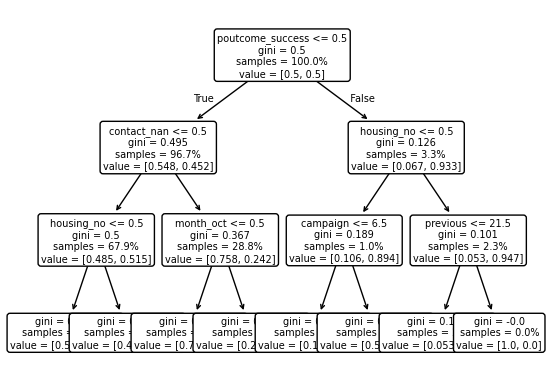

In [79]:
visualize_tree(decision_tree)

In [80]:
max_depths = list(range(1, 31)) + [40, 50]
train_scores = []
test_scores = []

for d in tqdm(max_depths):
    estimator = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=d, class_weight="balanced")
    train_score, test_score, _ = cross_validation(estimator)
    train_scores.append(train_score)
    test_scores.append(test_score)

100%|██████████| 32/32 [01:12<00:00,  2.27s/it]


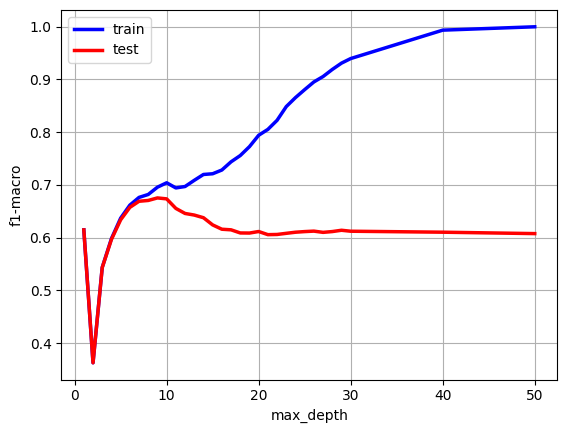

In [81]:
plt.plot(max_depths, train_scores, label="train", color="blue", linewidth=2.5)
plt.plot(max_depths, test_scores, label="test", color="red", linewidth=2.5)
plt.grid(visible=True)
plt.xlabel("max_depth")
plt.ylabel("f1-macro")
plt.legend()
plt.show()

In [82]:
depth_estimators_score_triples = zip(max_depths, test_scores)
sorted_depth_score_pairs = sorted(depth_estimators_score_triples, key=lambda it: it[1], reverse=True)

print("-----Decision tree-----\n")
print(f"{'Depth':<15}{'F1-macro':<10}")
for depth, score in sorted_depth_score_pairs[:5]:
    print(f"{depth:<15}{round(score, 3):<10.3f}")

-----Decision tree-----

Depth          F1-macro  
9              0.675     
10             0.674     
8              0.671     
7              0.669     
6              0.657     


In [83]:
from sklearn.utils import compute_sample_weight

sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_values
)

In [84]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(random_state=RANDOM_STATE)
gradient_boosting.fit(X_values, y_values, sample_weight=sample_weight)

GradientBoostingClassifier(random_state=42)

In [85]:
feature_importances = gradient_boosting.feature_importances_

for score, name in sorted(zip(feature_importances, features), reverse=True):
    if score > 0:
        print(f"{name:<30}{score}")

poutcome_success              0.2769397668558448
contact_nan                   0.157826186231585
age                           0.06439691839374559
housing_yes                   0.04921373718992535
day_of_week                   0.045506767820815454
balance                       0.04538698988470769
pdays                         0.039554007353010394
month_mar                     0.03664169527224647
campaign                      0.03286297785301291
month_oct                     0.03257342312284485
housing_no                    0.028974671869478788
month_jun                     0.02800772372839069
month_apr                     0.02247907987844047
month_sep                     0.0154974480674487
loan_yes                      0.014866615200114293
marital_married               0.013853859412819297
month_feb                     0.013633417621723605
marital_single                0.01200207788704507
month_nov                     0.011486083499989932
contact_cellular              0.008997921958227

In [86]:
for i, (est, ) in enumerate(gradient_boosting.estimators_):
    print(f"{i:<20}{est}")

0                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7CE48B6D5740)
1                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7CE48B6D5740)
2                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7CE48B6D5740)
3                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7CE48B6D5740)
4                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7CE48B6D5740)
5                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7CE48B6D5740)
6                   DecisionTreeRegressor(criterion='friedman_ms

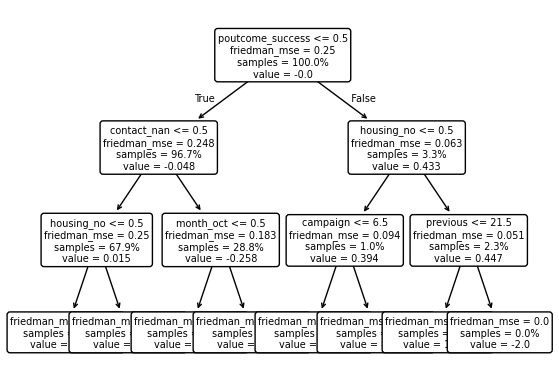

In [87]:
visualize_tree(gradient_boosting.estimators_[0][0])

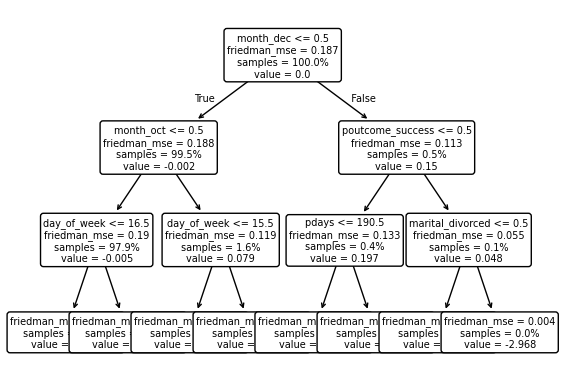

In [88]:
visualize_tree(gradient_boosting.estimators_[50][0])

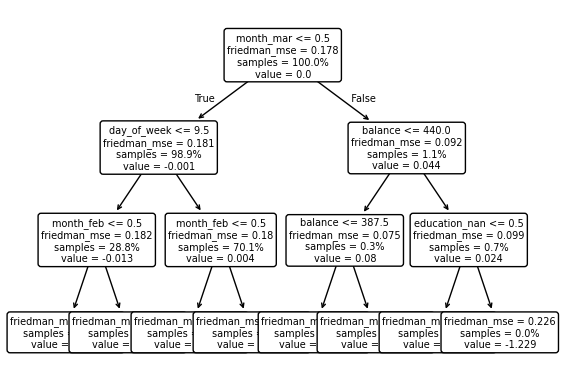

In [89]:
visualize_tree(gradient_boosting.estimators_[99][0])

In [90]:
max_depths = [1, 2, 3, 4, 5, 10, 20, 30, 40]
estimator_number = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]

train_scores = {}
test_scores = {}

for d in max_depths:
    train_scores[d] = []
    test_scores[d] = []

for (d, n) in tqdm(list(product(max_depths, estimator_number))):
    estimator = GradientBoostingClassifier(random_state=RANDOM_STATE, max_depth=d, n_estimators=n)
    train_score, test_score, _ = cross_validation(estimator, params={"sample_weight": sample_weight})
    train_scores[d].append(train_score)
    test_scores[d].append(test_score)

100%|██████████| 126/126 [4:36:19<00:00, 131.58s/it]


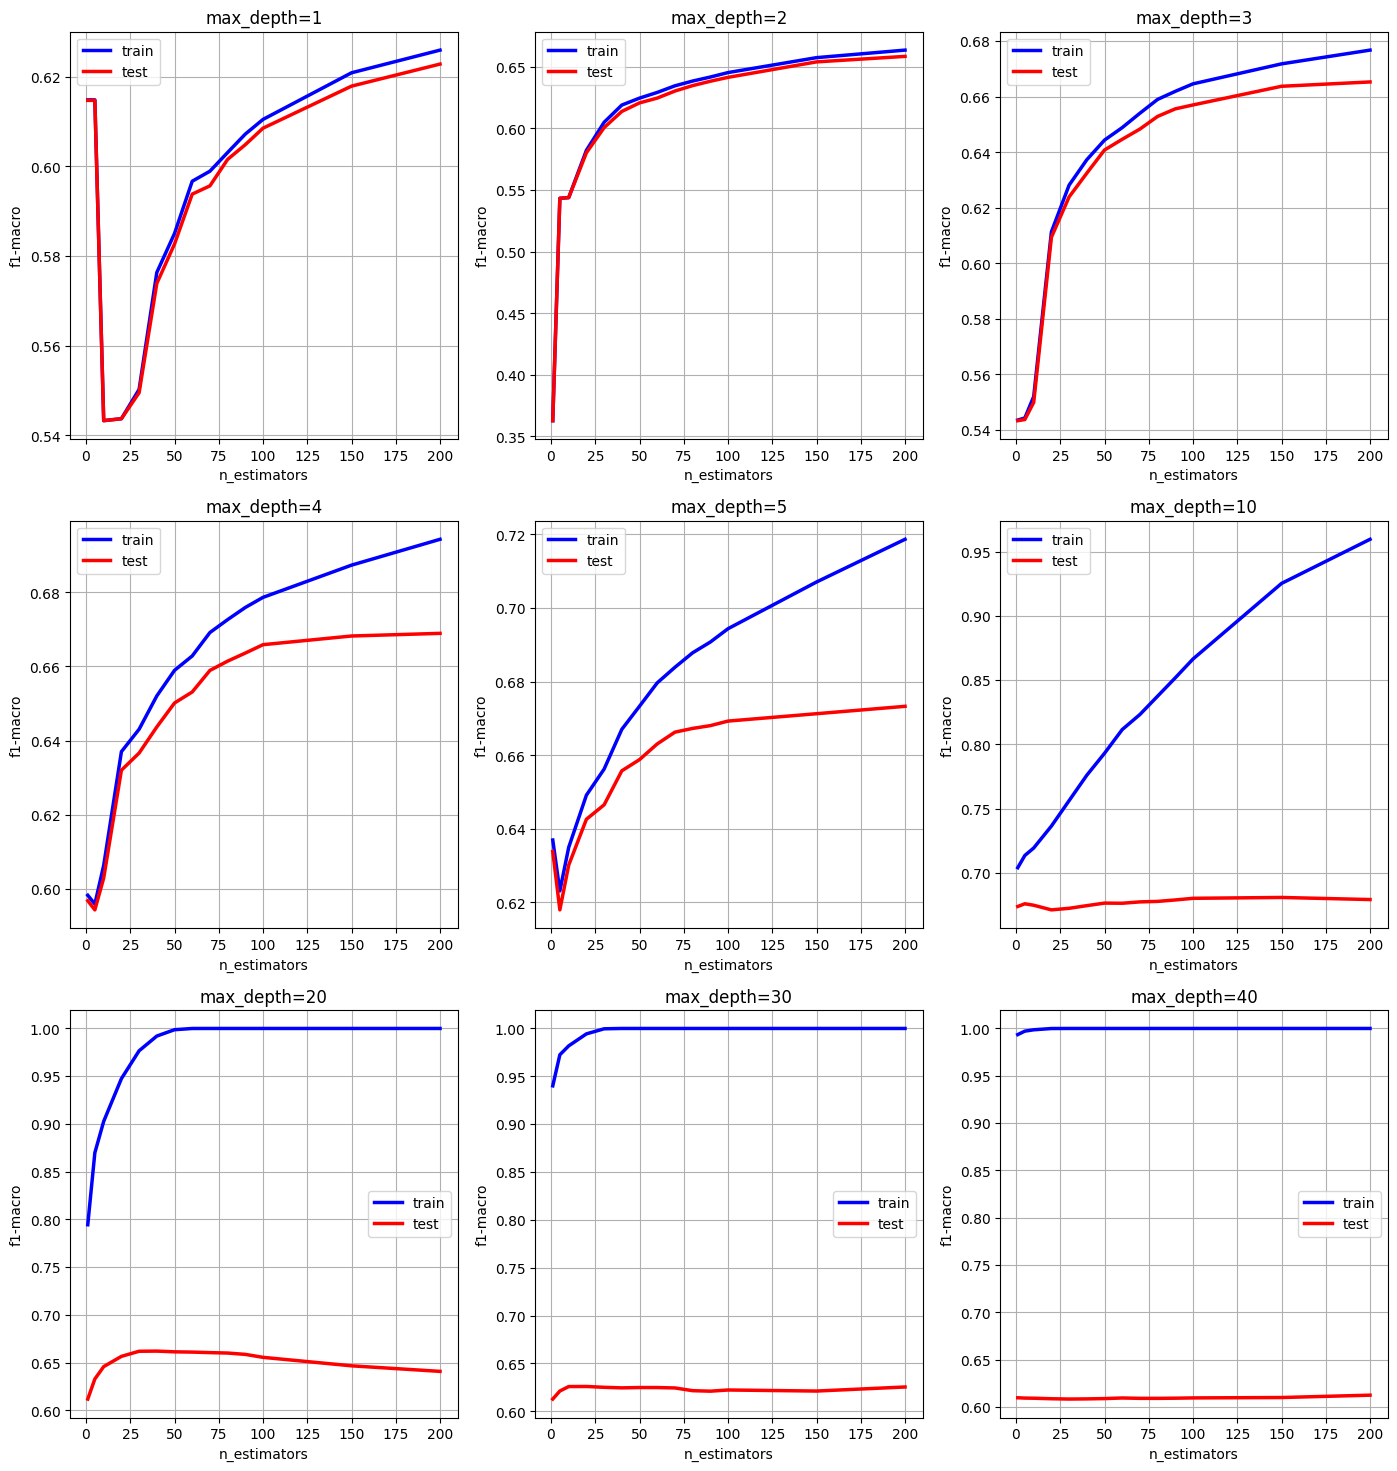

In [91]:
fig, sub = plt.subplots(3, 3, figsize=(17, 18))
for d, ax in zip(max_depths, sub.flatten()):
    ax.grid(visible=True)
    ax.plot(estimator_number, train_scores[d], label="train", color="blue", linewidth=2.5)
    ax.plot(estimator_number, test_scores[d], label="test", color="red", linewidth=2.5)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("f1-macro")
    ax.set_title(f"max_depth={d}")
    ax.legend()
plt.show()

In [92]:
depth_estimators_score_triples = []
for d in max_depths:
    for i, n in enumerate(estimator_number):
        depth_estimators_score_triples.append((d, n, test_scores[d][i]))

sorted_depth_estimators_score_triples = sorted(depth_estimators_score_triples, key=lambda it: it[2], reverse=True)

print("------------Gradient Boosting------------\n")
print(f"{'Depth':<15}{'Estimators':<15}{'F1-macro':<10}")
for depth, estimators, score in sorted_depth_estimators_score_triples[:10]:
    print(f"{depth:<15}{estimators:<15}{round(score, 3):<10.3f}")

------------Gradient Boosting------------

Depth          Estimators     F1-macro  
10             150            0.681     
10             100            0.680     
10             200            0.679     
10             90             0.679     
10             80             0.678     
10             70             0.677     
10             50             0.676     
10             60             0.676     
10             5              0.676     
10             10             0.675     


In [93]:
import warnings
from sklearn.ensemble import RandomForestClassifier

# Ignore UserWarning: "Some inputs do not have OOB scores."
warnings.filterwarnings("ignore", category=UserWarning)

max_depths = [1, 2, 3, 4, 5, 10, 20, 30, 40]
estimator_number = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]

train_scores = {}
test_scores = {}
oob_scores = {}

for d in max_depths:
    train_scores[d] = []
    test_scores[d] = []
    oob_scores[d] = []

for (d, n) in tqdm(list(product(max_depths, estimator_number))):
    estimator = RandomForestClassifier(
        random_state=RANDOM_STATE,
        max_depth=d,
        n_estimators=n,
        bootstrap=True,
        n_jobs=-1,
        oob_score=f1_macro,
        class_weight="balanced_subsample"
    )

    train_score, test_score, estimators = cross_validation(estimator)
    estimators_oob_score = np.array([e.oob_score_ for e in estimators])
    oob_score = estimators_oob_score.mean()

    train_scores[d].append(train_score)
    test_scores[d].append(test_score)
    oob_scores[d].append(oob_score)

100%|██████████| 126/126 [26:55<00:00, 12.82s/it]


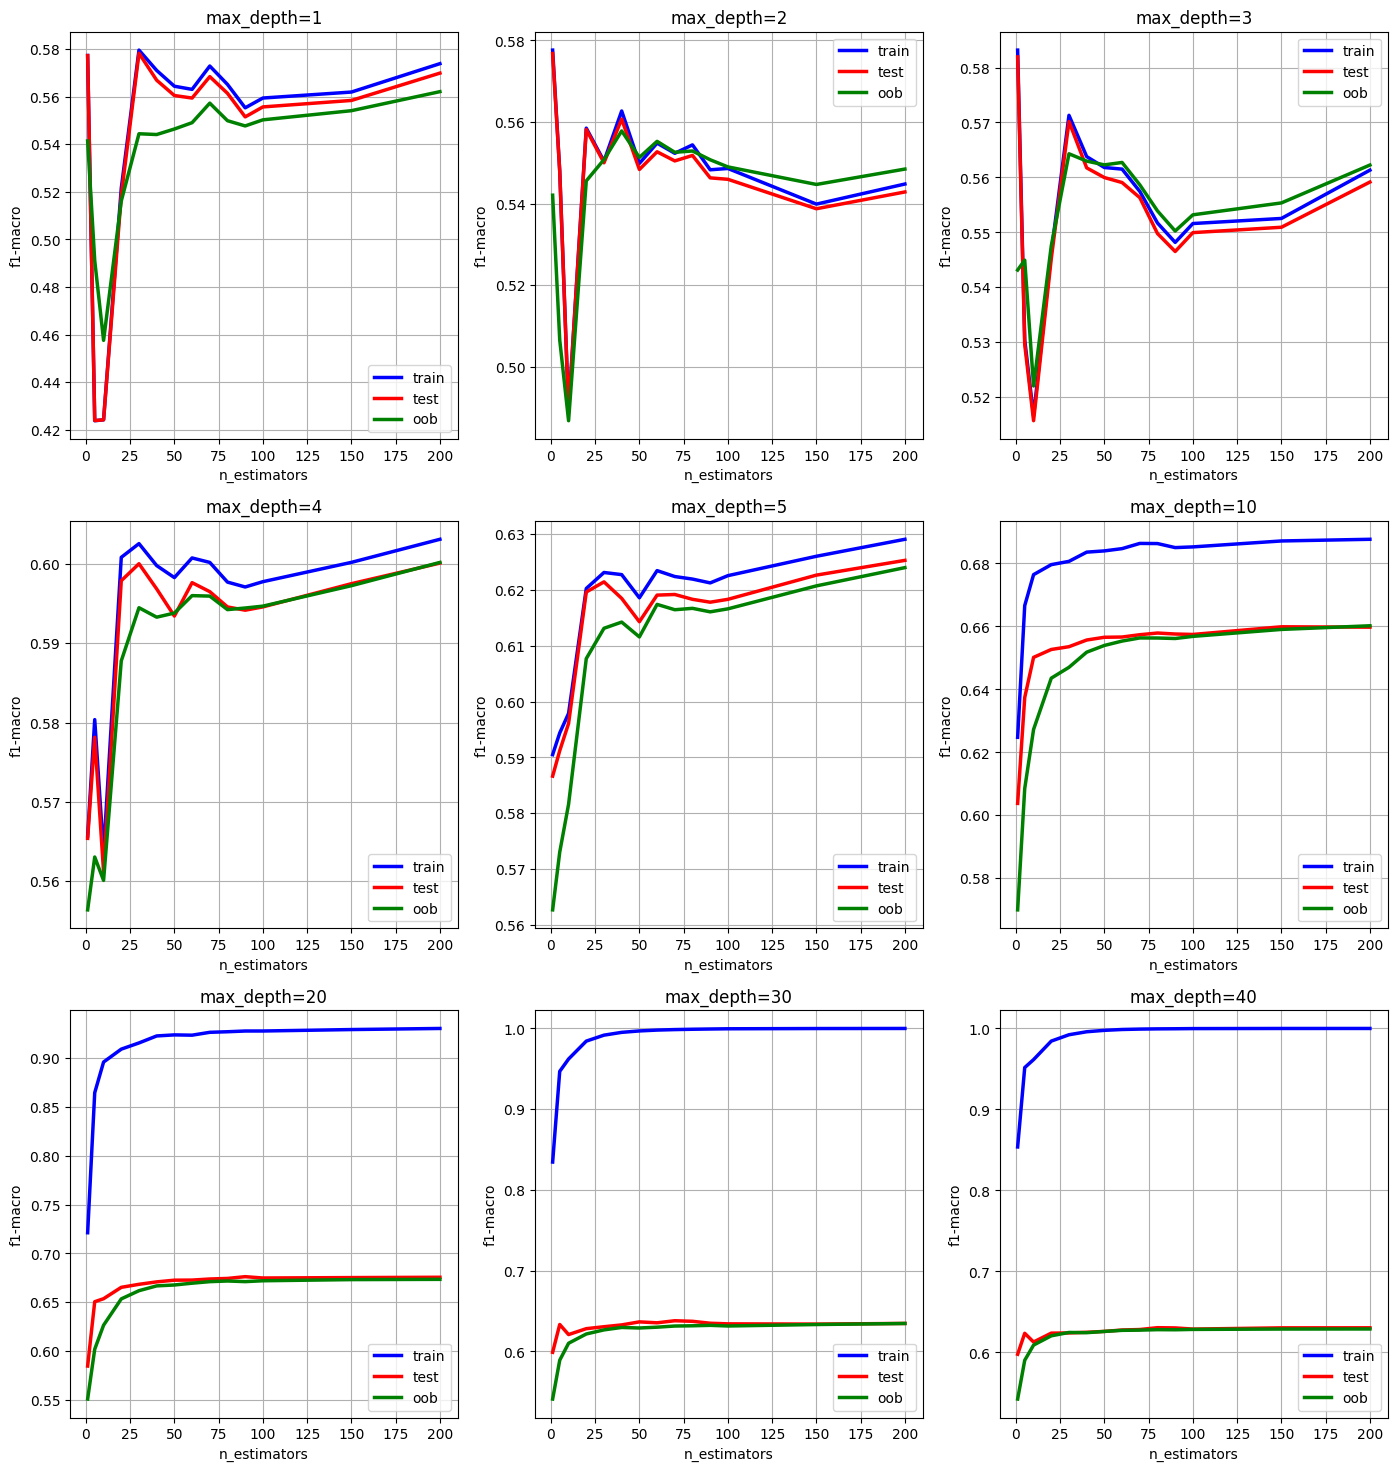

In [94]:
fig, sub = plt.subplots(3, 3, figsize=(17, 18))
for d, ax in zip(max_depths, sub.flatten()):
    ax.grid(visible=True)
    ax.plot(estimator_number, train_scores[d], label="train", color="blue", linewidth=2.5)
    ax.plot(estimator_number, test_scores[d], label="test", color="red", linewidth=2.5)
    ax.plot(estimator_number, oob_scores[d], label="oob", color="green", linewidth=2.5)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("f1-macro")
    ax.set_title(f"max_depth={d}")
    ax.legend()
plt.show()

In [95]:
depth_estimators_test_oob_fours = []
for d in max_depths:
    for i, n in enumerate(estimator_number):
        depth_estimators_test_oob_fours.append((d, n, oob_scores[d][i], test_scores[d][i]))

sorted_depth_estimators_test_oob_fours = sorted(depth_estimators_test_oob_fours, key=lambda it: it[2] + it[3], reverse=True)

print("----------------------------Random Forest----------------------------\n")
print(f"{'Depth':<15}{'Estimators':<15}{'F1-macro (test)':<22}{'F1-macro (OOB)':<22}")
for depth, estimators, test_score, oob_score in sorted_depth_estimators_test_oob_fours[:10]:
    print(f"{depth:<15}{estimators:<15}{round(test_score, 3):<22.3f}{round(oob_score, 3):<22.3f}")

----------------------------Random Forest----------------------------

Depth          Estimators     F1-macro (test)       F1-macro (OOB)        
20             200            0.673                 0.675                 
20             150            0.673                 0.675                 
20             90             0.671                 0.676                 
20             100            0.672                 0.675                 
20             80             0.672                 0.674                 
20             70             0.671                 0.674                 
20             60             0.669                 0.673                 
20             50             0.668                 0.672                 
20             40             0.667                 0.671                 
20             30             0.662                 0.668                 
